# Notebook 7 – Backpropagation & Gradients



## 1. What is a gradient?

A **gradient** tells us how much a value such as loss changes when a model parameter changes.

In simple words:

> A gradient tells the model which direction a parameter should move to reduce the error.

If the gradient is:

- **positive**, decreasing the parameter can reduce the loss
- **negative**, increasing the parameter can reduce the loss
- **close to zero**, the loss is changing very little around that parameter

For a single variable, a gradient is similar to a slope.

### Real-world example

Imagine walking down a hill while trying to reach the lowest point.

The slope tells you how the ground is changing. You can use that information to decide which direction to move.

### AI/ML usage

Gradients are used to learn neural-network parameters such as:

- weights
- biases

They are also used in many optimization-based machine-learning algorithms.

## 2. Why are gradients required?

A neural network starts with parameters that may not produce good predictions.

We need a way to answer:

> Which weight should change, and by how much?

The loss tells us **how wrong** the prediction is.

The gradient tells us **how the parameters contributed to that error and which direction they should move**.

So:

**Loss = tells us how wrong the model is**

**Gradient = tells us how to change the parameters**

### Real-world example

Suppose an online store predicts that a customer will spend ₹1,000 but the actual spending is ₹1,500.

The loss shows that the prediction is wrong.

The gradients help the learning algorithm decide how the model parameters should change so that future predictions can become closer to the actual value.

### AI/ML usage

Gradients are the main signal used during neural-network training. Without gradients, gradient-based optimization would not know how to adjust the learned parameters efficiently.

## 3. Gradient Descent

**Gradient descent** is an optimization method used to reduce the loss.

The basic update idea is:

**new parameter = old parameter − learning rate × gradient**

The learning rate controls the size of the step.

- Small learning rate → smaller updates
- Large learning rate → larger updates

### Real-world example

Think about trying to find the lowest point of a valley while looking at the slope around you.

You take a step in the direction that goes downhill.

### AI/ML usage

Gradient descent and its variants are widely used to train neural networks.

Common optimizers include:

- SGD
- Adam
- RMSprop

The optimizer uses gradients to update model parameters.

## 4. A very small mathematical example

Let the model be:

**ŷ = wx + b**

Choose:

- x = 2
- actual y = 10
- w = 3
- b = 1

### Step 1: Forward pass

ŷ = 3 × 2 + 1 = 7

The model predicts **7** while the actual value is **10**.

### Step 2: Calculate loss

I will use:

**L = 1/2 (ŷ − y)²**

So:

L = 1/2 (7 − 10)² = 4.5

### Step 3: Calculate gradients

First:

**dL/dŷ = ŷ − y = -3**

Because:

**ŷ = wx + b**

we get:

**dŷ/dw = x = 2**

and:

**dŷ/db = 1**

Using the chain rule:

**dL/dw = dL/dŷ × dŷ/dw = -3 × 2 = -6**

**dL/db = dL/dŷ × dŷ/db = -3 × 1 = -3**

### Step 4: Update parameters

Take learning rate = 0.1.

New w:

3 − 0.1 × (-6) = **3.6**

New b:

1 − 0.1 × (-3) = **1.3**

The negative gradients cause the parameters to increase.

This is the basic idea behind learning.

In [1]:
x = 2.0
y = 10.0
w = 3.0
b = 1.0
learning_rate = 0.1

y_hat = w * x + b
loss = 0.5 * (y_hat - y) ** 2

d_loss_d_yhat = y_hat - y
d_yhat_d_w = x
d_yhat_d_b = 1.0

d_loss_d_w = d_loss_d_yhat * d_yhat_d_w
d_loss_d_b = d_loss_d_yhat * d_yhat_d_b

new_w = w - learning_rate * d_loss_d_w
new_b = b - learning_rate * d_loss_d_b

print("Prediction:", y_hat)
print("Loss:", loss)
print("Gradient for w:", d_loss_d_w)
print("Gradient for b:", d_loss_d_b)
print("Updated w:", new_w)
print("Updated b:", new_b)

Prediction: 7.0
Loss: 4.5
Gradient for w: -6.0
Gradient for b: -3.0
Updated w: 3.6
Updated b: 1.3


### My interpretation

The prediction started at **7**, while the actual value was **10**.

The gradients were negative, so gradient descent increased both `w` and `b`.

After one update:

- `w` moved from 3.0 to 3.6
- `b` moved from 1.0 to 1.3

This moves the model toward a prediction that is closer to the actual value.

The important point is that the model did not randomly change its parameters. The gradients gave the direction of the update.

## 5. Computational Graph

A **computational graph** represents calculations as a sequence of connected operations.

For the small example:

**x → multiplication with w → addition with b → prediction → loss**

More explicitly:

**x, w → wx**

**wx, b → ŷ**

**ŷ, y → loss**

During the forward pass, values move from inputs toward the loss.

During the backward pass, gradient information moves backward through the same calculation structure.

### Real-world example

A computational graph is similar to a recipe.

A recipe has steps that depend on previous steps. If the final dish is not good, we can trace backward through the steps to understand which quantities affected the final result.

### AI/ML usage

Deep-learning frameworks build and track computation relationships so that gradients can be calculated automatically during training.

## 6. Forward Pass

The **forward pass** is the process of sending input data through the model to produce a prediction.

For a simple neuron:

**input → weighted calculation → activation → output**

For a training example:

**Input → Model → Prediction → Loss**

### Real-world example

A bank model receives customer information and produces a prediction such as an estimated risk score.

### AI/ML usage

Every training iteration begins with a forward pass. The model uses its current weights and biases to produce predictions.

## 7. Loss Calculation

The **loss function** measures the difference between the model's prediction and the expected target.

A larger loss generally means the prediction is farther from the target for that particular loss definition.

### Real-world example

If a model predicts that a product will sell 100 units but the actual value is 150, the loss measures the prediction error.

### AI/ML usage

Loss provides the objective that the optimizer tries to minimize.

Examples include:

- MSE for many regression problems
- Binary Cross Entropy for binary classification
- Cross Entropy for multiclass classification

## 8. Backward Pass

The **backward pass** starts from the loss and moves backward through the computational graph.

Its purpose is to calculate how much each parameter contributed to the loss.

This produces gradients such as:

- gradient of loss with respect to a weight
- gradient of loss with respect to a bias

### Real-world example

Imagine a product recommendation system gives a poor recommendation. A backward analysis traces the error through the model's calculations and determines how the learned parameters should be adjusted.

### AI/ML usage

The backward pass is the main step that provides the gradients needed by the optimizer.

## 9. Chain Rule

The **chain rule** is the mathematical rule that allows us to calculate the effect of one variable through several connected calculations.

Suppose:

**a → b → c**

If we want to know how `c` changes with `a`, we can multiply the local changes:

**dc/da = dc/db × db/da**

In the neural-network example:

**loss → prediction → weighted sum → weight**

So the gradient can be calculated by multiplying the local derivatives along the path.

### Real-world example

If a final product score depends on several stages of processing, the chain rule helps determine how a change at an earlier stage affects the final score.

### AI/ML usage

Backpropagation is essentially an efficient application of the chain rule across a neural network.

## 10. Backpropagation

**Backpropagation** is the process of calculating gradients of the loss with respect to the model's parameters by moving backward through the computational graph.

It combines:

1. the forward pass
2. loss calculation
3. the chain rule
4. the backward pass

A useful mental model is:

**Forward:** What prediction did the model make?

**Loss:** How wrong was it?

**Backward:** Which parameters affected that error?

**Gradient:** In which direction should those parameters move?

### Real-world example

If a neural network predicts the wrong category for an image, backpropagation calculates how the network's parameters contributed to that wrong prediction.

### AI/ML usage

Backpropagation is one of the fundamental mechanisms used to train neural networks.

## 11. Weight Update

Once gradients are available, an optimizer updates the weights.

The basic idea is:

**weight_new = weight_old − learning_rate × gradient**

The optimizer repeats this process over many training examples and iterations.

### Real-world example

Think of adjusting the settings of a machine after measuring how far the output is from the desired result.

### AI/ML usage

Weight updates allow the neural network to gradually learn patterns from training data.

The process is repeated until the loss becomes sufficiently small or another stopping condition is reached.

## 12. The complete learning cycle

The full training idea can now be connected:

**1. Forward Pass**

Input enters the model and produces a prediction.

**2. Calculate Loss**

The prediction is compared with the target.

**3. Backward Pass**

The loss is propagated backward.

**4. Calculate Gradients**

Gradients tell us how the loss changes with respect to the parameters.

**5. Update Weights**

The optimizer changes the parameters using the gradients.

So the complete chain is:

**Forward Pass → Calculate Loss → Backward Pass → Calculate Gradients → Update Weights**

Then the cycle repeats.

## 13. PyTorch `requires_grad=True`

PyTorch can automatically track operations involving tensors.

When we create a tensor with:

`requires_grad=True`

we are telling PyTorch:

> Track the operations on this tensor because I may need the gradient later.

This is especially useful for model parameters such as weights and biases.

### AI/ML usage

During training, neural-network parameters require gradients because the optimizer needs those gradients to update the parameters.

In [2]:
import torch

x = torch.tensor(2.0, requires_grad=True)
y = x ** 2

print("x:", x)
print("y:", y)
print("requires_grad:", x.requires_grad)

x: tensor(2., requires_grad=True)
y: tensor(4., grad_fn=<PowBackward0>)
requires_grad: True


Here, `y = x²`.

The derivative is:

**dy/dx = 2x**

At x = 2:

**dy/dx = 4**

PyTorch can calculate this automatically when we call `.backward()`.

In [3]:
y.backward()

print("Gradient of y with respect to x:", x.grad)

Gradient of y with respect to x: tensor(4.)


## 14. `.backward()` and `.grad`

### `.backward()`

Calling:

`y.backward()`

tells PyTorch to perform the backward pass and calculate gradients for the tracked tensors that contributed to `y`.

### `.grad`

The `.grad` attribute stores the gradient that PyTorch calculated.

For the previous example:

**y = x²**

At x = 2:

**dy/dx = 4**

Therefore `x.grad` becomes 4.

### AI/ML usage

During neural-network training, `.backward()` is used to calculate gradients of the loss, and parameter `.grad` values are then used by the optimizer.

## 15. A small PyTorch neuron example

Now I will reproduce the earlier mathematical example using PyTorch.

The model is:

**ŷ = wx + b**

I will calculate the loss and let PyTorch calculate the gradients.

This is useful because it shows that the mathematical process and the PyTorch implementation are describing the same idea.

In [4]:
x = torch.tensor(2.0)
target = torch.tensor(10.0)

w = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

prediction = w * x + b
loss = 0.5 * (prediction - target) ** 2

loss.backward()

print("Prediction:", prediction.item())
print("Loss:", loss.item())
print("Gradient of w:", w.grad.item())
print("Gradient of b:", b.grad.item())

Prediction: 7.0
Loss: 4.5
Gradient of w: -6.0
Gradient of b: -3.0


### Interpretation

The output should match the manual calculation:

- prediction = 7
- loss = 4.5
- gradient of `w` = -6
- gradient of `b` = -3

This is the key idea of **autograd**: I defined the forward calculation, and PyTorch automatically tracked the operations and calculated the required gradients during the backward pass.

## 16. What is PyTorch Autograd?

**Autograd** is PyTorch's automatic differentiation system.

It tracks operations on tensors that require gradients and builds the information needed to calculate derivatives.

When `.backward()` is called, PyTorch uses this tracked computation history to calculate gradients.

### Why is this useful?

Manually calculating gradients becomes difficult when a neural network contains:

- many layers
- many neurons
- thousands or millions of parameters
- multiple activation functions

Autograd performs the derivative calculations automatically.

### AI/ML usage

Autograd is a core part of PyTorch model training. It makes backpropagation practical for large neural networks.

## 17. Using the uploaded retail dataset

Now I will connect the concepts to the actual dataset.

First I will load the CSV and inspect the available columns.

The dataset contains transaction-level retail information. I will focus on positive quantities and valid prices for a simple regression demonstration.

In [5]:
import pandas as pd
import numpy as np

data_path = "data.csv"
df = pd.read_csv(data_path, encoding="latin1")

print("Shape:", df.shape)
print("Columns:", list(df.columns))
print(df[["Quantity", "UnitPrice"]].head())

Shape: (541909, 8)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
   Quantity  UnitPrice
0         6       2.55
1         6       3.39
2         8       2.75
3         6       3.39
4         6       3.39


The important columns for this notebook are:

- `Quantity`: number of items in the transaction
- `UnitPrice`: price of one item
- `Revenue`: a derived value calculated as quantity multiplied by unit price

I am using a derived revenue target because it gives us a simple continuous value for demonstrating gradient-based regression.

In [6]:
work = df[["Quantity", "UnitPrice"]].dropna().copy()
work = work[(work["Quantity"] > 0) & (work["UnitPrice"] > 0)]
work["Revenue"] = work["Quantity"] * work["UnitPrice"]

work = work.sample(n=min(1000, len(work)), random_state=42)

print("Rows used:", len(work))
print(work.head())
print(work[["Quantity", "UnitPrice", "Revenue"]].describe())

Rows used: 1000
        Quantity  UnitPrice  Revenue
269788         2       7.95    15.90
83138          4       4.25    17.00
538681         3       4.15    12.45
58905          1       0.65     0.65
388858         6       0.85     5.10
          Quantity   UnitPrice      Revenue
count  1000.000000  1000.00000  1000.000000
mean      9.417000     3.99848    19.978170
std      23.914326    15.19559    54.488588
min       1.000000     0.19000     0.190000
25%       1.000000     1.25000     4.130000
50%       3.000000     2.10000     9.900000
75%      10.000000     4.76250    17.085000
max     384.000000   469.70000  1056.000000


## 18. Dataset-based gradient example

For a simple demonstration, I will use:

**Input X = Quantity**

**Target y = Revenue**

The model is:

**ŷ = wx + b**

This is a very small linear model, not a complete deep-learning solution.

The purpose is to observe the same learning cycle:

**Input → Prediction → Loss → Gradients → Weight update**

Because revenue also depends on unit price, quantity alone will not perfectly predict every transaction's revenue. That is useful here because the model has an actual error to learn from.

In [7]:
X = torch.tensor(work["Quantity"].values, dtype=torch.float32).reshape(-1, 1)
y = torch.tensor(work["Revenue"].values, dtype=torch.float32).reshape(-1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("First input:", X[0].item())
print("First target:", y[0].item())

X shape: torch.Size([1000, 1])
y shape: torch.Size([1000, 1])
First input: 2.0
First target: 15.899999618530273


### Why reshape the data?

PyTorch models commonly expect tabular input in the form:

**number of rows × number of features**

Here there is one feature, so the shape is:

**n × 1**

The target is also kept as:

**n × 1**

This makes the matrix operations easier to understand.

In [8]:
X_mean = X.mean()
X_std = X.std()
y_mean = y.mean()
y_std = y.std()

X_scaled = (X - X_mean) / X_std
y_scaled = (y - y_mean) / y_std

print("Scaled input mean:", X_scaled.mean().item())
print("Scaled target mean:", y_scaled.mean().item())

Scaled input mean: 9.53674295089968e-09
Scaled target mean: -1.2636184543168838e-08


### Why scale the values?

Retail quantities and revenues can have very different numerical sizes.

Scaling makes the values easier for a simple gradient-descent demonstration to work with.

I am using standardization:

**scaled value = (value − mean) / standard deviation**

The target is also scaled here so that the learning rate can be kept simple.

In [9]:
w = torch.tensor([[0.0]], dtype=torch.float32, requires_grad=True)
b = torch.tensor([0.0], dtype=torch.float32, requires_grad=True)

learning_rate = 0.05
epochs = 100

loss_history = []

for epoch in range(epochs):
    prediction = X_scaled @ w + b
    loss = torch.mean((prediction - y_scaled) ** 2)

    loss.backward()

    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

    w.grad.zero_()
    b.grad.zero_()

    loss_history.append(loss.item())

print("Initial learning setup completed")
print("Final weight:", w.item())
print("Final bias:", b.item())
print("Final loss:", loss_history[-1])

Initial learning setup completed
Final weight: 0.7538200616836548
Final bias: -1.909211100326047e-08
Final loss: 0.43129295110702515


### What happened in this training loop?

For every epoch:

1. `prediction` performs the forward pass.
2. `loss` measures prediction error.
3. `loss.backward()` performs the backward pass.
4. `w.grad` and `b.grad` contain the gradients.
5. The parameters are updated using the learning rate.
6. The gradients are reset before the next iteration.

This is the same basic learning cycle used in neural networks, although real neural networks have many more parameters and layers.

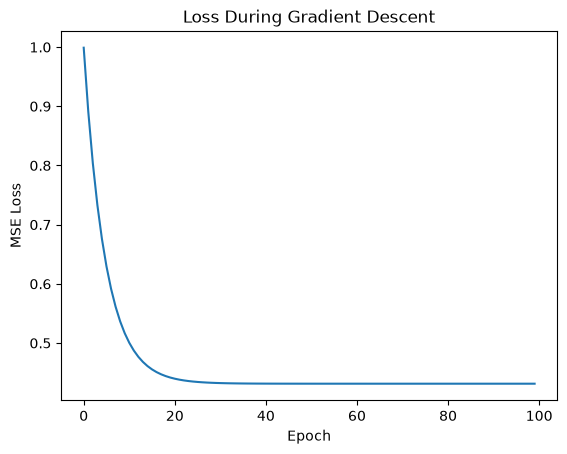

In [10]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss During Gradient Descent")
plt.show()

### Interpreting the loss graph

If the training is working correctly, the loss should generally move downward as the epochs increase.

A downward loss means the model's predictions are becoming closer to the training targets according to the MSE loss.

The exact curve can vary because the dataset is noisy and the model uses only one feature.

The important learning point is:

**The gradient gives the direction for changing the parameters, and repeated updates can reduce the loss.**

## 19. Seeing gradients directly on the dataset example

It is useful to stop training and inspect the gradient values at one point in the process.

The gradient is not the prediction and it is not the loss.

- Prediction = model output
- Loss = error measure
- Gradient = direction and rate of change of loss with respect to a parameter

In [11]:
w_demo = torch.tensor([[0.0]], dtype=torch.float32, requires_grad=True)
b_demo = torch.tensor([0.0], dtype=torch.float32, requires_grad=True)

prediction_demo = X_scaled @ w_demo + b_demo
loss_demo = torch.mean((prediction_demo - y_scaled) ** 2)

loss_demo.backward()

print("Loss:", loss_demo.item())
print("Gradient of w:", w_demo.grad.item())
print("Gradient of b:", b_demo.grad.item())

Loss: 0.9989998936653137
Gradient of w: -1.5061731338500977
Gradient of b: 2.2351741790771484e-08


### Interpretation

At the initial parameter values, the gradients tell us how the loss would change if we changed the weight or bias.

The optimizer uses this information to decide the next parameter values.

This is why gradients are so important: they connect the loss calculation to the parameter update.